In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import lstsq
import warnings
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.nelson_siegel import fit_ns, ns_yields, ns_forward, ns_loadings
from config import maturities, PORTFOLIO, VALUATION_DATE
from fred_data import load_fred_data

warnings.filterwarnings('ignore')

In [5]:
yields = load_fred_data()

In [6]:
bond_yields = yields.loc[VALUATION_DATE]

In [7]:
NS = fit_ns(maturities, bond_yields)
def discount(tau, params):
    return np.exp(-ns_yields(tau, params['b0'], params['b1'], params['b2'], params['lam'])/100 * tau)

def price_bond(coupon_rate, maturity, face_value=100.0, freq=2, params=NS):
    dt = 1/freq
    times = np.arange(dt, maturity+dt, dt)
    cash_flows = np.full(len(times), coupon_rate*face_value*dt/100)
    cash_flows[-1] += face_value
    discounts = discount(times, params)
    present_values = cash_flows * discounts
    bond_price = present_values.sum()
    duration = (times*present_values).sum() / bond_price
    convexity = (times**2 * present_values).sum() / bond_price
    ytm = _ytm(cash_flows, times, bond_price)
    modified_duration = duration / (1 + ytm/freq)
    return dict(price=bond_price,
                duration=duration,
                convexity = convexity,
                ytm=ytm*100,
                modified_duration=modified_duration,
                present_values=present_values,
                cash_flows=cash_flows,
                discounts=discounts,
                times=times)

def _ytm(cash_flows, times, bond_price, total=1e-9, iterations=300):
    y=0.04
    for _ in range(iterations):
        pv = np.sum(cash_flows * np.exp(-y*times))
        dpv = -np.sum(times * cash_flows * np.exp(-y*times))
        dy = (pv-bond_price) / dpv
        y-=dy
        if abs(y)<total:
            break
    return y

rows=[]
for name, coupon_rate, maturity, face_value in PORTFOLIO:
    bond_metrics = price_bond(coupon_rate, maturity, face_value)
    market_value = bond_metrics['price'] * 1e6
    dv01 = bond_metrics['modified_duration'] * market_value * 0.0001
    rows.append({
        'Bond': name,
        'Coupon Rate (%)': coupon_rate,
        'Maturity (years)': maturity,
        'Face Value ($)': face_value,
        'Price ($)': bond_metrics['price'],
        'Market Value ($)': market_value,
        'YTM (%)': bond_metrics['ytm'],
        'Duration (years)': bond_metrics['duration'],
        'Modified Duration (years)': bond_metrics['modified_duration'],
        'Convexity': bond_metrics['convexity'],
        'DV01 ($)': dv01
    })

portfolio_df = pd.DataFrame(rows)
portfolio_df


,Bond,Coupon Rate (%),Maturity (years),Face Value ($),Price ($),Market Value ($),YTM (%),Duration (years),Modified Duration (years),Convexity,DV01 ($)
0,UST 4.750% 2026,4.750,2.0,50,50.895561,5.089556e+07,3.775509,1.932315,1.896513,3.808558,9652.409983
1,UST 3.875% 2029,3.875,5.0,120,120.744778,1.207448e+08,3.703259,4.595590,4.512044,22.254180,54480.572759
2,UST 3.875% 2034,3.875,10.0,90,91.185307,9.118531e+07,3.682009,8.399864,8.248018,78.696606,75209.800856
3,UST 4.250% 2054,4.250,30.0,40,43.948885,4.394889e+07,3.668429,17.850939,17.529412,432.138189,77039.811227


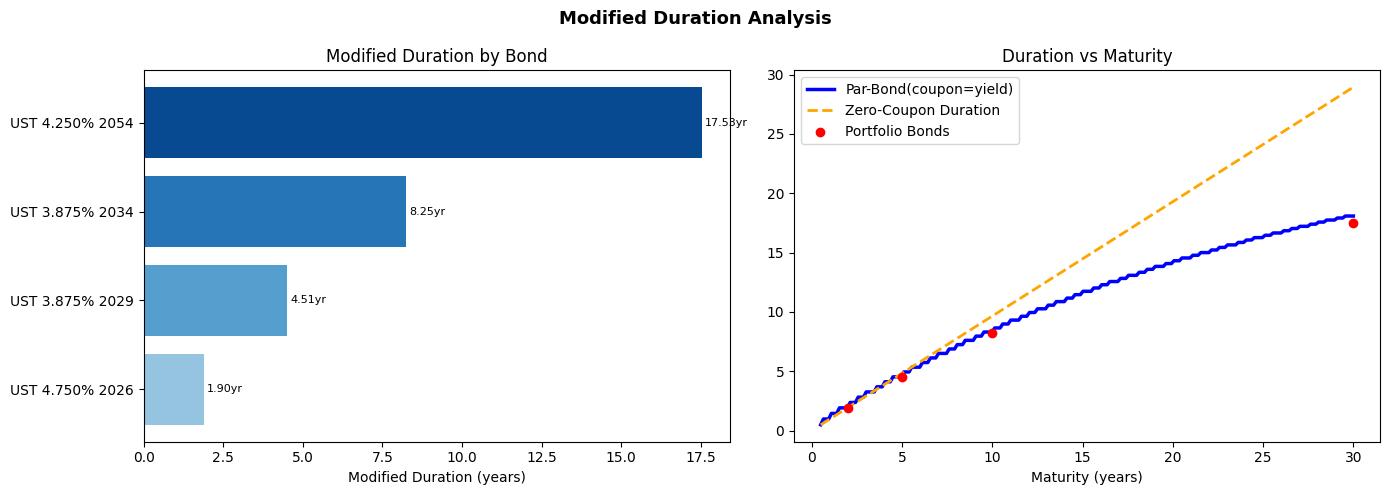

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Duration by bond ────────────────────────────────────────────────
ax = axes[0]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(portfolio_df)))
bars = ax.barh(portfolio_df['Bond'], portfolio_df['Modified Duration (years)'], color=colors)
ax.set_xlabel('Modified Duration (years)')
ax.set_title('Modified Duration by Bond')
for bar, val in zip(bars, portfolio_df['Modified Duration (years)']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}yr', va='center', fontsize=8)


tau_range = np.linspace(0.5,30,200)
par_yields = ns_yields(tau_range, NS['b0'], NS['b1'], NS['b2'], NS['lam'])
mod_duration = [price_bond(rate, maturity)['modified_duration'] for rate, maturity in zip(par_yields, tau_range)]
zero_duration = tau_range/(1 + par_yields/100)

ax1 = axes[1]
ax1.plot(tau_range, mod_duration, lw=2.5, label='Par-Bond(coupon=yield)', color='blue')
ax1.plot(tau_range, zero_duration, lw=2.0, label='Zero-Coupon Duration', color='orange', linestyle='--')
ax1.scatter(portfolio_df['Maturity (years)'], portfolio_df['Modified Duration (years)'], color='red', label='Portfolio Bonds', zorder=5)
ax1.set_xlabel('Maturity (years)')
ax1.set_title('Duration vs Maturity')
ax1.legend()  

plt.suptitle('Modified Duration Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pf_mv = portfolio_df['Market Value ($)'].sum()
pf_duration = (portfolio_df['Modified Duration (years)'] * portfolio_df['Market Value ($)']/1e6).sum() / pf_mv/1e6

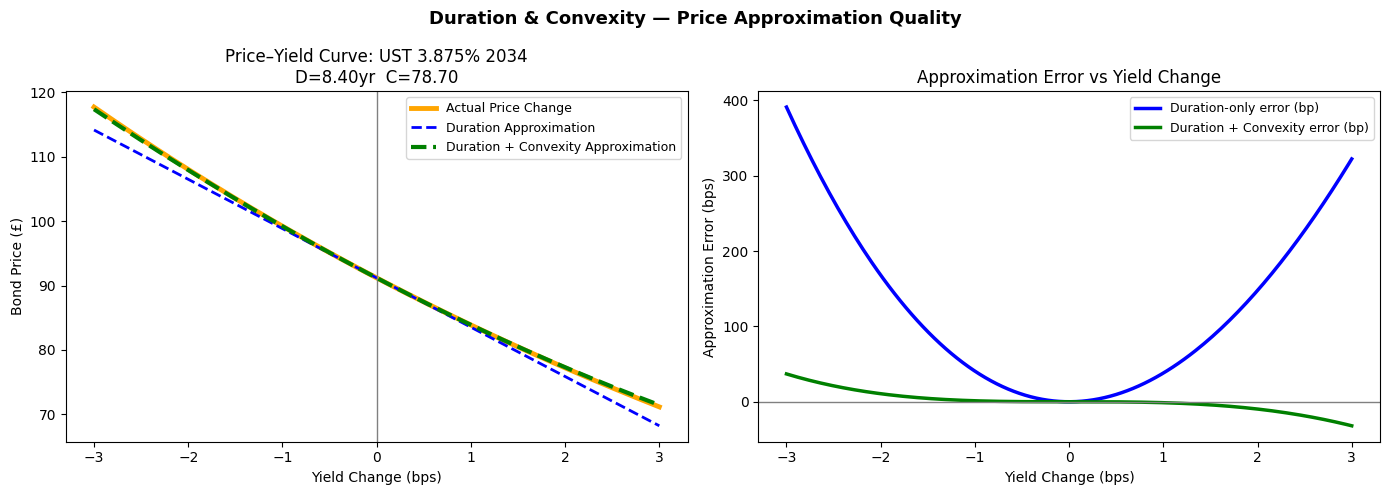

In [38]:
bond_name, coupon_rate, maturity, face_value = PORTFOLIO[2]
dy_range = np.linspace(-0.03,0.03,200)
initial_metrics = price_bond(coupon_rate, maturity, face_value)
P0, D, C = initial_metrics['price'], initial_metrics['duration'], initial_metrics['convexity']

actual_price_changes = [price_bond(coupon_rate, maturity, face_value, params=dict(b0 = NS['b0'] + dy*100,
                                                                                b1 = NS['b1'],
                                                                                b2 =  NS['b2'],
                                                                                lam = NS['lam']))['price']
                            for dy in dy_range
]

approx_price_change_duration = P0 *(1 - D * dy_range)
approx_price_change_convexity = P0 *(1 - D * dy_range + 0.5 * C * dy_range**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(dy_range*100, actual_price_changes, lw = 3.5, label='Actual Price Change', color='orange')
ax.plot(dy_range*100, approx_price_change_duration, lw = 2.0, label='Duration Approximation', color='blue', linestyle='--')
ax.plot(dy_range*100, approx_price_change_convexity, lw = 3.0, label='Duration + Convexity Approximation', color='green', zorder=10, linestyle='--')
ax.axvline(0, color='grey', lw=1)
ax.set_xlabel('Yield Change (bps)')
ax.set_ylabel('Bond Price (£)')
ax.set_title(f'Price–Yield Curve: {bond_name}\nD={D:.2f}yr  C={C:.2f}')
ax.legend(fontsize=9)

ax=axes[1]
error_duration = (np.array(actual_price_changes) - np.array(approx_price_change_duration)) / P0 * 10000
error_convexity = (np.array(actual_price_changes) - np.array(approx_price_change_convexity)) / P0 * 10000
ax.plot(dy_range*100, error_duration, lw=2.5, label='Duration-only error (bp)', color='blue')
ax.plot(dy_range*100, error_convexity, lw=2.5, label='Duration + Convexity error (bp)', color='green')
ax.axhline(0, color='grey', lw=1)
ax.set_xlabel('Yield Change (bps)')
ax.set_ylabel('Approximation Error (bps)')
ax.set_title('Approximation Error vs Yield Change')
ax.legend(fontsize=9) 

plt.suptitle('Duration & Convexity — Price Approximation Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

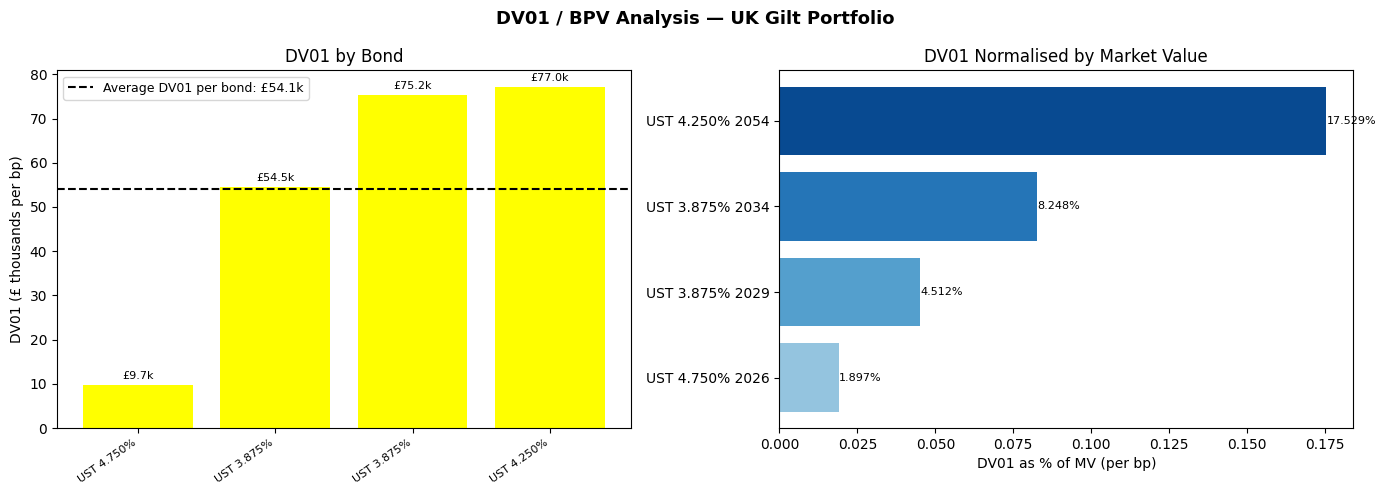

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ['yellow' if d>0 else 'red' for d in portfolio_df['DV01 ($)']]
bars = ax.bar(range(len(portfolio_df)), portfolio_df['DV01 ($)']/1000, color=colors)
ax.set_xticks(range(len(portfolio_df)))
ax.set_xticklabels(portfolio_df['Bond'], rotation=45, ha='right')
ax.set_xticklabels([b.split()[0]+' '+b.split()[1] for b in portfolio_df['Bond']],
                    rotation=35, ha='right', fontsize=8)
ax.set_ylabel('DV01 (£ thousands per bp)')
ax.set_title('DV01 by Bond')
for bar, val in zip(bars, portfolio_df['DV01 ($)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'£{val/1000:.1f}k', ha='center', fontsize=8)

total_dv01 = portfolio_df['DV01 ($)'].sum()
ax.axhline(total_dv01/len(portfolio_df)/1000, color='black', ls='--', lw=1.5,
           label=f'Average DV01 per bond: £{total_dv01/len(portfolio_df)/1000:.1f}k')
ax.legend(fontsize=9)

ax = axes[1]
dv01_pct = portfolio_df['DV01 ($)'] / (portfolio_df['Market Value ($)']) * 100  # % per bp
ax.barh(portfolio_df['Bond'], dv01_pct, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(portfolio_df))))
ax.set_xlabel('DV01 as % of MV (per bp)')
ax.set_title('DV01 Normalised by Market Value')
for i, v in enumerate(dv01_pct):
    ax.text(v + 0.0002, i, f'{v*100:.3f}%', va='center', fontsize=8)

plt.suptitle('DV01 / BPV Analysis — UK Gilt Portfolio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

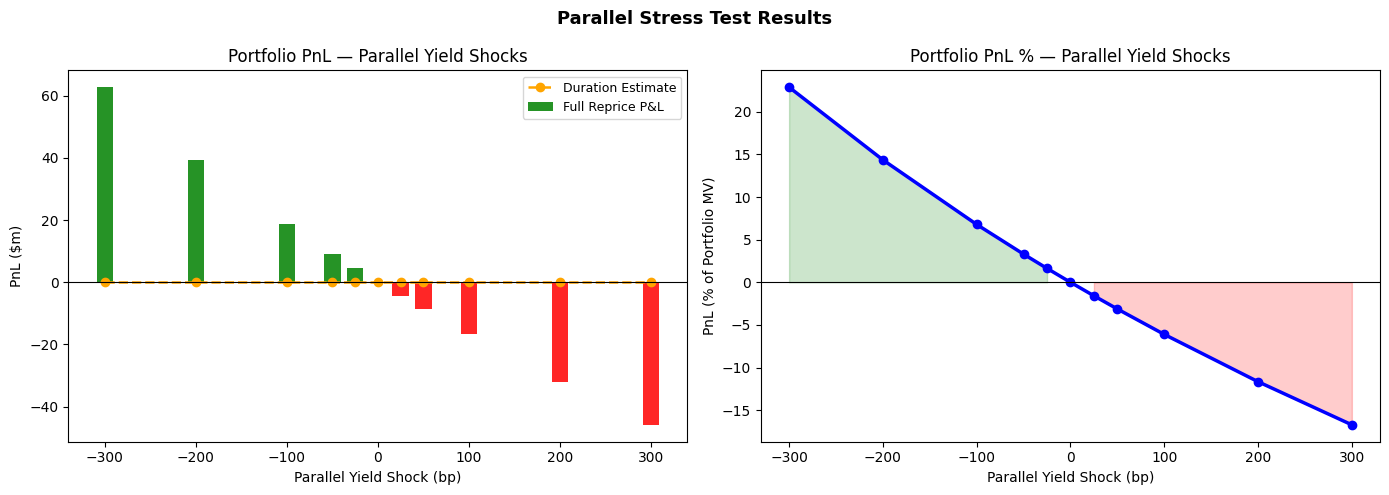

In [40]:
shocks_bp = [-300, -200, -100, -50, -25, 0, 25, 50, 100, 200, 300]

def portfolio_mv(shock_bp, params=NS):
    shocked_params = dict(b0 = params['b0'] + shock_bp/100,
                          b1 = params['b1'],
                          b2 = params['b2'],
                          lam = params['lam'])
    total_mv = 0
    for _, rows in portfolio_df.iterrows():
        bond_price = price_bond(rows['Coupon Rate (%)'], rows['Maturity (years)'], rows['Face Value ($)'], params=shocked_params)['price']
        total_mv += bond_price/100 * rows['Market Value ($)']
    return total_mv

base_mv = portfolio_mv(0)
results = []
for shock in shocks_bp:
    shocked_mv = portfolio_mv(shock)
    change = shocked_mv - base_mv
    mv_pct_change = change / base_mv * 100
    results.append({
        'Shock (bp)': shock,
        'Portfolio MV ($m)': shocked_mv/1e6,
        'PnL ($m)': change/1e6,
        'PnL (%)': mv_pct_change
    })

stress_df = pd.DataFrame(results)

stress_df['Estimated Duration ($m)'] = [-pf_duration * base_mv/1e6 * s/100 for s in shocks_bp]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(stress_df['Shock (bp)'], stress_df['PnL ($m)'],
       color=['red' if v < 0 else 'green' for v in stress_df['PnL ($m)']],
       width=18, alpha=0.85, label='Full Reprice P&L')
ax.plot(stress_df['Shock (bp)'], stress_df['Estimated Duration ($m)'],
        'o--', color='orange', lw=1.8, label='Duration Estimate')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Parallel Yield Shock (bp)')
ax.set_ylabel('PnL ($m)')
ax.set_title('Portfolio PnL — Parallel Yield Shocks')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(stress_df['Shock (bp)'], stress_df['PnL (%)'], 'o-', color='blue', lw=2.5)
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(stress_df['Shock (bp)'], stress_df['PnL (%)'], 0,
                where=stress_df['PnL (%)'] < 0, alpha=0.2, color='red')
ax.fill_between(stress_df['Shock (bp)'], stress_df['PnL (%)'], 0,
                where=stress_df['PnL (%)'] > 0, alpha=0.2, color='green')
ax.set_xlabel('Parallel Yield Shock (bp)')
ax.set_ylabel('PnL (% of Portfolio MV)')
ax.set_title('Portfolio PnL % — Parallel Yield Shocks')

plt.suptitle('Parallel Stress Test Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pnl_100 = stress_df.loc[stress_df['Shock (bp)']==100, 'PnL ($m)'].values[0]
pnl_200 = stress_df.loc[stress_df['Shock (bp)']==200, 'PnL ($m)'].values[0]


Non-Parallel Scenario Analysis  (Base MV = $274.2m)
Bear Steepener (+50s/-100L): PnL = $ 49.39m
Bull Flattener (-100s/+50L): PnL = $ 28.63m
Bear Flattener (+100s/+25L): PnL = $ 23.93m
Bull Steepener (-25s/-100L): PnL = $ 52.76m
Belly Selloff (butterfly): PnL = $ -143.38m
Parallel +100bp: PnL = $ -16.77m
Parallel -100bp: PnL = $ 18.60m


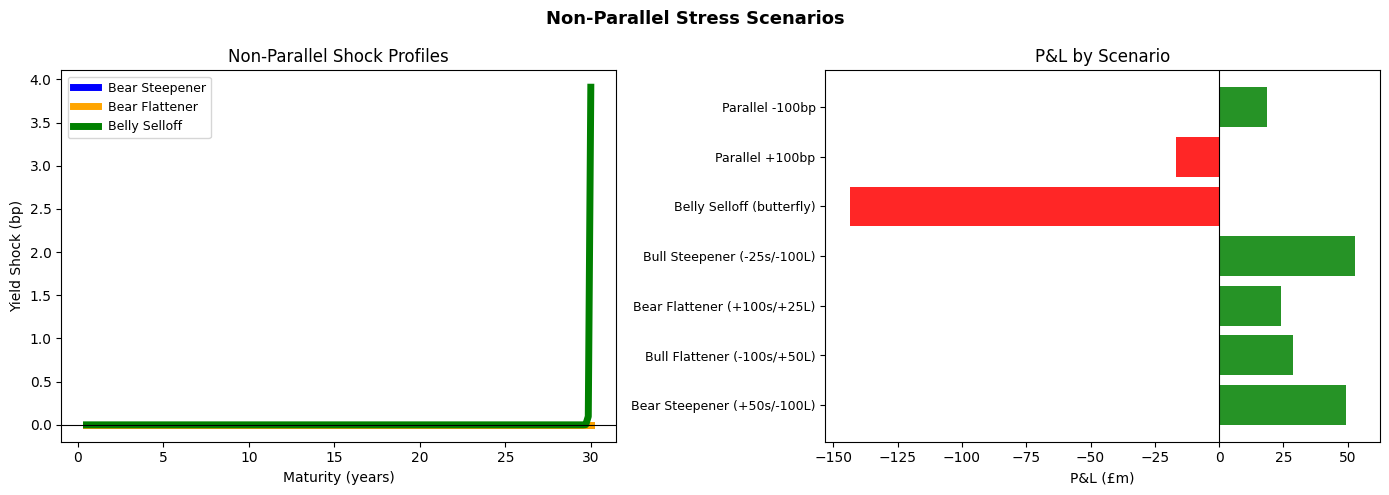

In [41]:
def nonparallel_shocks(short_shock, long_shock, mid_shock=0, short_cutoff=2, long_cutoff=10):
    
    total_mv = 0
    for _, rows in portfolio_df.iterrows():
        if rows['Maturity (years)'] <= short_cutoff:
            shock = short_shock
        elif rows['Maturity (years)'] >= long_cutoff:
            shock = long_shock
        else:
            t = (rows['Maturity (years)'] - short_cutoff) / (long_cutoff - short_cutoff)
            shock = short_shock * (1-t) + long_shock * t
        shock+= mid_shock * np.exp(0.5 * (rows['Maturity (years)']-5)**2)
        non_parallel_params = dict(b0 = NS['b0'] + shock/100,
                                   b1 = NS['b1'],
                                   b2 = NS['b2'],
                                   lam = NS['lam'])
        bond_price = price_bond(rows['Coupon Rate (%)'], rows['Maturity (years)'], params = non_parallel_params)['price']
        total_mv += bond_price/100 * rows['Face Value ($)'] * 1e6
    return total_mv

scenarios = {
    'Bear Steepener (+50s/-100L)': nonparallel_shocks(short_shock=+50, long_shock=-100),
    'Bull Flattener (-100s/+50L)': nonparallel_shocks(short_shock=-100, long_shock=+50),
    'Bear Flattener (+100s/+25L)': nonparallel_shocks(short_shock=+100, long_shock=+25),
    'Bull Steepener (-25s/-100L)': nonparallel_shocks(short_shock=-25, long_shock=-100),
    'Belly Selloff (butterfly)':   nonparallel_shocks(short_shock=0, long_shock=0, mid_shock=75),
    'Parallel +100bp':             portfolio_mv(+100),
    'Parallel -100bp':             portfolio_mv(-100),
}

print(f"Non-Parallel Scenario Analysis  (Base MV = ${base_mv/1e6:.1f}m)")
print("="*62)
for name, mv in scenarios.items():
    pnl = (mv - base_mv) / 1e6
    print(f'{name}: PnL = $ {pnl:.2f}m')

tau_vis = np.linspace(0.5, 30, 200)
def shock_profile(short, long, mid=0):
    profile = []
    for t in tau_vis:
        if t<=2: shock = short
        elif t>=10: shock = long
        else: shock = short* (1-(t-2)/8) + long*((t-2)/8)
        shock+= mid * np.exp(0.5 * (t-5)**2)
        profile.append(shock)
    return np.array(profile)

profiles = {
    'Bear Steepener': shock_profile(50, -100),
    'Bear Flattener': shock_profile(100, 25),
    'Belly Selloff':  shock_profile(0, 0, 75),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_s = ['blue', 'orange', 'green']
for (name, prof), col in zip(profiles.items(), colors_s):
    axes[0].plot(tau_vis, prof/1e137, color=col, lw=5, label=name)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xlabel('Maturity (years)')
axes[0].set_ylabel('Yield Shock (bp)')
axes[0].set_title('Non-Parallel Shock Profiles')
axes[0].legend(fontsize=9)

pnls = [(n, (mv-base_mv)/1e6) for n, mv in scenarios.items()]
names_s, vals_s = zip(*pnls)
colors_bar = ['green' if v > 0 else 'red' for v in vals_s]
axes[1].barh(range(len(names_s)), vals_s, color=colors_bar, alpha=0.85)
axes[1].set_yticks(range(len(names_s)))
axes[1].set_yticklabels(names_s, fontsize=9)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('P&L (£m)')
axes[1].set_title('P&L by Scenario')

plt.suptitle('Non-Parallel Stress Scenarios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


np.float64(274.15924145081226)